In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\pc\anaconda3\envs\python_course\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.stats import gaussian_kde


In [ ]:
df_Da = df.query("job_title_short == 'Data Analyst' and job_country == 'United States'")

df_Da = df_Da.dropna(subset='salary_year_avg')

df_exploded = df_Da.explode('job_skills')

df_exploded = df_exploded.groupby('job_skills')['salary_year_avg'].agg(skill_count='count', median_salary='median').sort_values(by= 'skill_count', ascending= False)[:9]

df_exploded['count_percent'] = df_exploded['skill_count'] / len(df_Da) * 100




109       {'analyst_tools': ['alteryx', 'tableau'], 'pro...
109       {'analyst_tools': ['alteryx', 'tableau'], 'pro...
109       {'analyst_tools': ['alteryx', 'tableau'], 'pro...
109       {'analyst_tools': ['alteryx', 'tableau'], 'pro...
180              {'analyst_tools': ['excel', 'powerpoint']}
                                ...                        
784882    {'analyst_tools': ['tableau', 'excel', 'altery...
784882    {'analyst_tools': ['tableau', 'excel', 'altery...
784882    {'analyst_tools': ['tableau', 'excel', 'altery...
784882    {'analyst_tools': ['tableau', 'excel', 'altery...
784882    {'analyst_tools': ['tableau', 'excel', 'altery...
Name: job_type_skills, Length: 17440, dtype: object

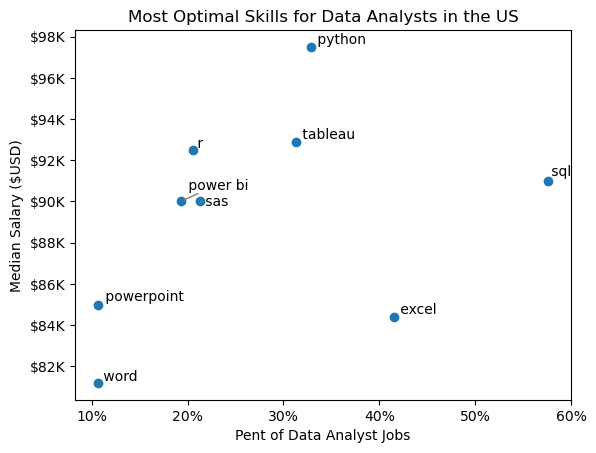

In [48]:
from adjustText import adjust_text

plt.scatter(df_exploded['count_percent'], df_exploded['median_salary'])
plt.xlabel('Pent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}%'))

texts = []
for i, txt in enumerate(df_exploded.index):
    texts.append(plt.text(df_exploded['count_percent'].iloc[i], df_exploded['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

In [ ]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) 
    for key, value in row_dict.items():
        if key in technology_dict: 
            technology_dict[key] += value
        else:                       
            technology_dict[key] = value


for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

       
    

        
        

{'analyst_tools': ['dax',
  'datarobot',
  'msaccess',
  'outlook',
  'qlik',
  'nuix',
  'esquisse',
  'sap',
  'spss',
  'sas',
  'alteryx',
  'ssis',
  'spreadsheet',
  'tableau',
  'visio',
  'power bi',
  'powerpoint',
  'ms access',
  'microstrategy',
  'looker',
  'sheets',
  'powerbi',
  'cognos',
  'ssrs',
  'excel',
  'word',
  'splunk',
  'sharepoint'],
 'programming': ['shell',
  'c#',
  'lua',
  'java',
  'sass',
  'sql',
  'typescript',
  'visual basic',
  'fortran',
  'perl',
  'vb.net',
  'delphi',
  'visualbasic',
  'nosql',
  'javascript',
  'scala',
  'lisp',
  'clojure',
  'html',
  'f#',
  'sas',
  'swift',
  'pascal',
  'solidity',
  'c',
  'elixir',
  't-sql',
  'go',
  'groovy',
  'bash',
  'ocaml',
  'mongo',
  'c++',
  'kotlin',
  'powershell',
  'mongodb',
  'matlab',
  'julia',
  'dart',
  'objective-c',
  'assembly',
  'haskell',
  'r',
  'rust',
  'erlang',
  'apl',
  'python',
  'golang',
  'crystal',
  'no-sql',
  'vba',
  'ruby',
  'cobol',
  'css',
  '